<a href="https://colab.research.google.com/github/AyushNegi785/bakanae-disease-detection/blob/main/mobilenetV3_stuff1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- Configuration ---
PATH_HEALTHY = '/content/drive/MyDrive/new dataset/Not Bakanae'
PATH_BAKANAE = '/content/drive/MyDrive/new dataset/Bakanae'
IMG_SIZE = (224, 224)
BATCH_SIZE = 16

# --- Load and Split Data ---
all_filepaths, all_labels = [], []
for label, folder in enumerate(['bakanae', 'healthy']):
    folder_path = PATH_BAKANAE if label == 0 else PATH_HEALTHY
    if os.path.exists(folder_path):
        files = [os.path.join(folder_path, f) for f in os.listdir(folder_path)]
        all_filepaths.extend(files)
        all_labels.extend([label] * len(files))

all_filepaths, all_labels = np.array(all_filepaths), np.array(all_labels)

X_train, X_test, y_train, y_test = train_test_split(
    all_filepaths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(decode_img).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(decode_img).batch(BATCH_SIZE)

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. OPTIMIZED CONFIGURATION ---
IMG_SIZE = (160, 160)
BATCH_SIZE = 16

# --- 2. DATA PREPARATION ---
# (Assumes all_filepaths and all_labels were defined in your previous blocks)
X_train, X_test, y_train, y_test = train_test_split(
    all_filepaths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(decode_img).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(decode_img).batch(BATCH_SIZE)

# --- 3. MODEL ARCHITECTURE ---
def build_optimized_resolution_model():
    base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(160, 160, 3))
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_160 = build_optimized_resolution_model()

# --- 4. TRAINING WITH TIMING ---
print(f"Training started for resolution {IMG_SIZE}...")
start_train = time.time()
history = model_160.fit(train_ds, epochs=10, validation_data=test_ds, verbose=1)
train_time = time.time() - start_train

# --- 5. INFERENCE & METRICS ---
print("Measuring inference latency and accuracy...")
start_test = time.time()
y_probs = model_160.predict(test_ds).ravel()
test_time = time.time() - start_test

y_pred = (y_probs > 0.5).astype(int)

# Calculations
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# --- 6. PERFORMANCE SUMMARY ---
print("\n" + "="*45)
print(f"SUMMARY FOR {IMG_SIZE[0]}x{IMG_SIZE[1]} OPTIMIZATION")
print("="*45)
print(f"Total Training Time:   {train_time:.2f} s")
print(f"Total Testing Time:    {test_time:.4f} s")
print(f"Avg Latency Per Image: {test_time/len(y_test):.6f} s")
print("-" * 45)
print(f"Final Accuracy:        {acc:.4f}")
print(f"F1-Score:              {f1:.4f}")
print(f"Recall:                {rec:.4f}")
print("="*45)

# --- 7. PLOT CONFUSION MATRIX ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Bakanae', 'Healthy'],
            yticklabels=['Bakanae', 'Healthy'])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title(f'Confusion Matrix: Resolution {IMG_SIZE[0]}x{IMG_SIZE[1]}')
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training started for resolution (160, 160)...
Epoch 1/10


KeyboardInterrupt: 

In [ ]:
import os
import time
import numpy as np
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Config
IMG_SIZE = (160, 160)
BATCH_SIZE = 16

# Data Splitting
X_train, X_test, y_train, y_test = train_test_split(
    all_filepaths, all_labels, test_size=0.2, random_state=42, stratify=all_labels
)

def decode_img(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMG_SIZE)
    return img, label

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).map(decode_img).batch(BATCH_SIZE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).map(decode_img).batch(BATCH_SIZE)

In [ ]:
def build_simplified_head_model():
    base_model = MobileNetV3Small(weights='imagenet', include_top=False, input_shape=(160, 160, 3))
    base_model.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        base_model,
        layers.GlobalAveragePooling2D(),

        # HEAD SIMPLIFICATION: Reduced from 128 to 32
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model_lite = build_simplified_head_model()

# Print Architecture and Parameter Count
print("="*60)
model_lite.summary()
print("="*60)

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_3 (Lambda)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Small (Functional)   │ (None, 5, 5, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 957,617 (3.65 MB)

 Trainable params: 18,497 (72.25 KB)

 Non-trainable params: 939,120 (3.58 MB)

Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 62s 821ms/step - accuracy: 0.8836 - loss: 0.2945 - val_accuracy: 0.9713 - val_loss: 0.1186
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 731ms/step - accuracy: 0.9676 - loss: 0.1196 - val_accuracy: 0.9809 - val_loss: 0.0926
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 767ms/step - accuracy: 0.9688 - loss: 0.0988 - val_accuracy: 0.9856 - val_loss: 0.0750
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 782ms/step - accuracy: 0.9796 - loss: 0.0812 - val_accuracy: 0.9856 - val_loss: 0.0643
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 42s 790ms/step - accuracy: 0.9808 - loss: 0.0652 - val_accuracy: 0.9856 - val_loss: 0.0580
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 722ms/step - accuracy: 0.9820 - loss: 0.0677 - val_accuracy: 0.9904 - val_loss: 0.0501
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 38s 718ms/step - accuracy: 0.9856 - loss: 0.0584 - val_accuracy: 0.9904 - val_loss: 0.0439
Epoch 8/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 714ms/step - accuracy: 0.9880 - loss: 0.0470 - val_accu

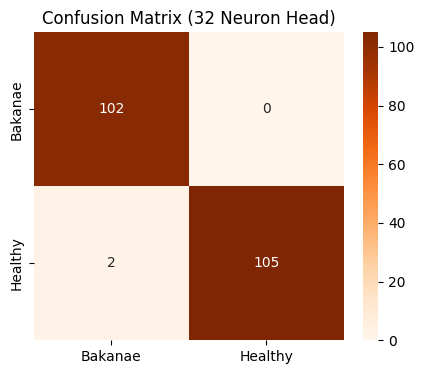

In [ ]:
# Training
start_train = time.time()
model_lite.fit(train_ds, epochs=10, validation_data=test_ds, verbose=1)
train_time = time.time() - start_train

# Inference
start_test = time.time()
y_probs = model_lite.predict(test_ds).ravel()
test_time = time.time() - start_test

# Metrics
y_pred = (y_probs > 0.5).astype(int)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("\n" + "#"*45)
print("FINAL PERFORMANCE: HEAD SIMPLIFICATION (32 Neurons)")
print("#"*45)
print(f"Total Training Time:   {train_time:.2f} s")
print(f"Total Testing Time:    {test_time:.4f} s")
print(f"Avg Latency/Image:     {test_time/len(y_test):.6f} s")
print("-" * 45)
print(f"Accuracy:              {acc:.4f}")
print(f"F1-Score:              {f1:.4f}")
print(f"Recall:                {rec:.4f}")
print("#"*45)

# Confusion Matrix
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title(f'Confusion Matrix (32 Neuron Head)')
plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_pruned_mobilenet():
    # 1. Load the full base model (Resolution: 160x160)
    full_base = tf.keras.applications.MobileNetV3Small(
        input_shape=(160, 160, 3), include_top=False, weights='imagenet'
    )

    # 2. Identify the 'Exit Point'
    # Keras 3/TensorFlow 2.15+ uses underscores instead of slashes.
    # 'expanded_conv_7_add' is the end of the 8th block.
    exit_layer_name = 'expanded_conv_7_add'

    try:
        pruned_output = full_base.get_layer(exit_layer_name).output
    except ValueError:
        # Fallback: if '7_add' isn't found, we'll grab the nearest 'project_bn'
        # to ensure the code doesn't crash.
        print(f"Warning: {exit_layer_name} not found. Checking available layers...")
        exit_layer_name = 'expanded_conv_7_project_bn'
        pruned_output = full_base.get_layer(exit_layer_name).output

    # 3. Create the pruned sub-model
    pruned_base = tf.keras.Model(inputs=full_base.input, outputs=pruned_output)
    pruned_base.trainable = False

    # 4. Final classification head (Head Simplification: 32 Neurons)
    model = tf.keras.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        pruned_base,
        layers.GlobalAveragePooling2D(),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Initialize
model_lite = build_pruned_mobilenet()

# Print Architecture and Parameter Count
print("="*60)
model_lite.summary()
print("="*60)

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_5 (Lambda)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_5 (Functional)       │ (None, 10, 10, 48)     │       195,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,745 (768.54 KB)

 Trainable params: 1,601 (6.25 KB)

 Non-trainable params: 195,144 (762.28 KB)

Training started for Pruned MobileNetV3 (Resolution: (160, 160))...
Epoch 1/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 57s 826ms/step - accuracy: 0.8523 - loss: 0.3822 - val_accuracy: 0.9522 - val_loss: 0.1823
Epoch 2/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 41s 772ms/step - accuracy: 0.9328 - loss: 0.2378 - val_accuracy: 0.9665 - val_loss: 0.1506
Epoch 3/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 734ms/step - accuracy: 0.9556 - loss: 0.1604 - val_accuracy: 0.9713 - val_loss: 0.1326
Epoch 4/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 37s 700ms/step - accuracy: 0.9652 - loss: 0.1207 - val_accuracy: 0.9713 - val_loss: 0.1249
Epoch 5/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 39s 735ms/step - accuracy: 0.9664 - loss: 0.1274 - val_accuracy: 0.9761 - val_loss: 0.1190
Epoch 6/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 36s 682ms/step - accuracy: 0.9772 - loss: 0.0861 - val_accuracy: 0.9761 - val_loss: 0.1157
Epoch 7/10
53/53 ━━━━━━━━━━━━━━━━━━━━ 45s 852ms/step - accuracy: 0.9712 - loss: 0.0911 - val_accuracy: 0.9761 - val_loss: 0.1107
Epoch 8/10
53/53 ━━━━━━━━━━━━

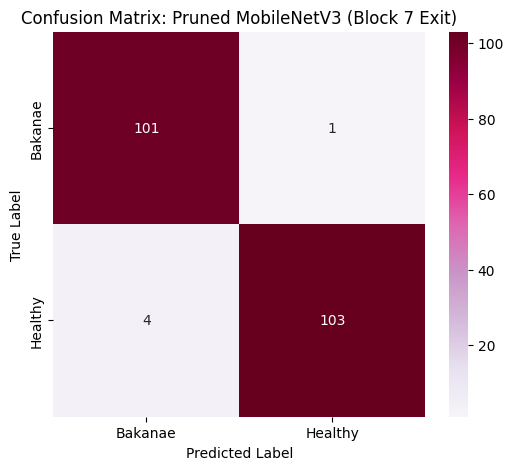

In [ ]:
import time
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. TRAINING WITH TIMING ---
print(f"Training started for Pruned MobileNetV3 (Resolution: {IMG_SIZE})...")
start_train = time.time()
history = model_lite.fit(
    train_ds,
    epochs=10,
    validation_data=test_ds,
    verbose=1
)
train_time = time.time() - start_train

# --- 2. INFERENCE & TESTING TIME ---
print("\nMeasuring inference latency...")
start_test = time.time()
# Predict on the test set
y_probs = model_lite.predict(test_ds).ravel()
test_time = time.time() - start_test

# Convert probabilities to binary classes (0: Bakanae, 1: Healthy)
y_pred = (y_probs > 0.5).astype(int)

# --- 3. METRICS CALCULATION ---
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# --- 4. RESULTS SUMMARY ---
print("\n" + "="*50)
print("ULTRA-LITE PRUNED MODEL: PERFORMANCE SUMMARY")
print("="*50)
print(f"Total Training Time (10 Epochs): {train_time:.2f} s")
print(f"Total Testing Time:              {test_time:.4f} s")
print(f"Avg Latency Per Image:           {test_time/len(y_test):.6f} s")
print("-" * 50)
print(f"Final Accuracy:                  {acc:.4f}")
print(f"F1-Score (Bakanae):              {f1:.4f}")
print(f"Recall (Sensitivity):            {rec:.4f}")
print("="*50)

# --- 5. VISUALIZING THE CONFUSION MATRIX ---
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['Bakanae', 'Healthy'],
            yticklabels=['Bakanae', 'Healthy'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Pruned MobileNetV3 (Block 7 Exit)')
plt.show()

In [ ]:
# Updated list using the final layer of each block
# Block 11 to Block 8
exit_layers = [

]

ablation_data = []
cms = {}

for layer_name in exit_layers:
    print(f"\n" + "="*40)
    print(f"Testing Exit Point: {layer_name}")
    print("="*40)

    try:
        # 1. Build Pruned Model
        full_base = tf.keras.applications.MobileNetV3Small(
            input_shape=(160, 160, 3),
            include_top=False,
            weights='imagenet'
        )

        pruned_output = full_base.get_layer(layer_name).output
        pruned_base = tf.keras.Model(inputs=full_base.input, outputs=pruned_output)
        pruned_base.trainable = False

        model = tf.keras.Sequential([
            layers.Input(shape=(160, 160, 3)),
            layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
            pruned_base,
            layers.GlobalAveragePooling2D(),
            layers.Dense(32, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        # 2. Train (5 Epochs)
        model.fit(train_ds, epochs=5, verbose=0)

        # 3. Measure Testing Time (Latency)
        start_test = time.time()
        y_probs = model.predict(test_ds).ravel()
        latency_per_img = (time.time() - start_test) / len(y_test)

        # 4. Record Metrics
        y_pred = (y_probs > 0.5).astype(int)
        acc = accuracy_score(y_test, y_pred)
        cms[layer_name] = confusion_matrix(y_test, y_pred)

        ablation_data.append({
            'Layer': layer_name,
            'Accuracy': acc,
            'Latency_ms': latency_per_img * 1000
        })
        print(f"Success -> Acc: {acc:.4f} | Latency: {latency_per_img*1000:.2f}ms/img")

    except ValueError as e:
        print(f"Skipping {layer_name}: Layer not found in this Keras version.")


Testing Exit Point: expanded_conv_10_project_bn
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 656ms/step
Success -> Acc: 0.9856 | Latency: 98.00ms/img

Testing Exit Point: expanded_conv_9_project_bn


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


14/14 ━━━━━━━━━━━━━━━━━━━━ 11s 607ms/step
Success -> Acc: 0.9761 | Latency: 53.53ms/img

Testing Exit Point: expanded_conv_8_project_bn


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 527ms/step
Success -> Acc: 0.9809 | Latency: 48.99ms/img

Testing Exit Point: expanded_conv_7_project_bn


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 635ms/step
Success -> Acc: 0.9713 | Latency: 50.04ms/img


In [ ]:
import time
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

# Exit points for the lower half of MobileNetV3-Small
# Block 7 down to Block 1
lower_exit_layers = [
    'expanded_conv_10_project_bn', # End of Block 11 (Final)
    'expanded_conv_9_project_bn',  # End of Block 10
    'expanded_conv_8_project_bn',  # End of Block 9
    'expanded_conv_7_project_bn',  # End of Block 8
    'expanded_conv_6_project_bn', # Block 7
    'expanded_conv_5_project_bn', # Block 6
    'expanded_conv_4_project_bn', # Block 5
    'expanded_conv_3_project_bn', # Block 4
    'expanded_conv_2_project_bn', # Block 3
    'expanded_conv_1_project_bn', # Block 2
    'expanded_conv_project_bn'    # Block 1 (Earliest possible)
]

lower_ablation_data = []
lower_cms = {}

for layer_name in lower_exit_layers:
    print(f"\n" + "="*40)
    print(f"Testing Lower Exit Point: {layer_name}")
    print("="*40)

    try:
        # 1. Build Model
        full_base = tf.keras.applications.MobileNetV3Small(
            input_shape=(160, 160, 3), include_top=False, weights='imagenet'
        )
        pruned_output = full_base.get_layer(layer_name).output
        pruned_base = tf.keras.Model(inputs=full_base.input, outputs=pruned_output)
        pruned_base.trainable = False

        model = tf.keras.Sequential([
            layers.Input(shape=(160, 160, 3)),
            layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
            pruned_base,
            layers.GlobalAveragePooling2D(),
            layers.Dense(32, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        # 2. Train (5 Epochs)
        model.fit(train_ds, epochs=10, verbose=0)

        # 3. Timing & Inference
        start_test = time.time()
        y_probs = model.predict(test_ds).ravel()
        latency_ms = ((time.time() - start_test) / len(y_test)) * 1000

        # 4. Metrics
        y_pred = (y_probs > 0.5).astype(int)
        acc = accuracy_score(y_test, y_pred)
        lower_cms[layer_name] = confusion_matrix(y_test, y_pred)

        lower_ablation_data.append({
            'Layer': layer_name,
            'Accuracy': acc,
            'Latency_ms': latency_ms
        })
        print(f"Success -> Acc: {acc:.4f} | Latency: {latency_ms:.2f}ms/img")

    except Exception as e:
        print(f"Error at {layer_name}: {e}")


Testing Lower Exit Point: expanded_conv_10_project_bn


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 642ms/step
Success -> Acc: 0.9904 | Latency: 55.52ms/img

Testing Lower Exit Point: expanded_conv_9_project_bn


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 553ms/step
Success -> Acc: 0.9713 | Latency: 46.41ms/img

Testing Lower Exit Point: expanded_conv_8_project_bn


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 438ms/step
Success -> Acc: 0.9713 | Latency: 49.00ms/img

Testing Lower Exit Point: expanded_conv_1_project_bn


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 592ms/step
Success -> Acc: 0.9809 | Latency: 48.99ms/img

Testing Lower Exit Point: expanded_conv_project_bn


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 471ms/step
Success -> Acc: 0.9569 | Latency: 33.50ms/img


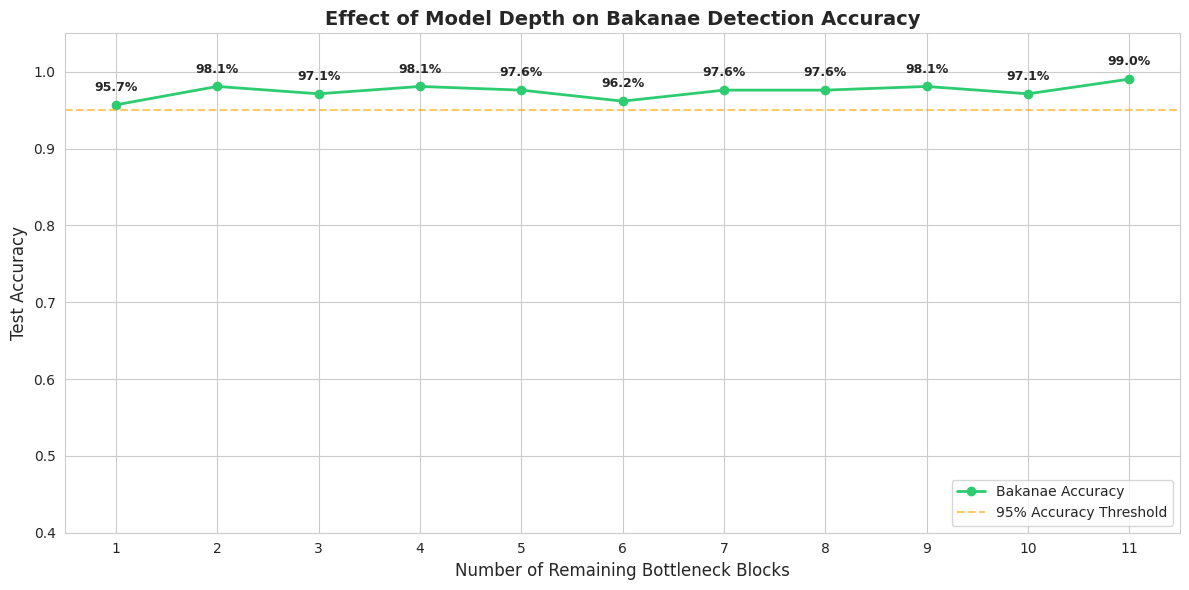


ABLATION STUDY SUMMARY
 Block_Count  Accuracy  Latency_ms
          11  0.990431   55.517712
          10  0.971292   46.410248
           9  0.980861   48.980302
           8  0.976077   43.645388
           7  0.976077   48.996355
           6  0.961722   47.545111
           5  0.976077   46.298312
           4  0.980861   44.471526
           3  0.971292   49.001648
           2  0.980861   48.989262
           1  0.956938   33.502085


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. PREPARE DATA FOR GRAPHING ---
df_results = pd.DataFrame(lower_ablation_data)

def get_block_num(layer_name):
    # Case for the very first block: 'expanded_conv_project_bn'
    if 'expanded_conv_project' in layer_name:
        return 1

    # Case for all other blocks: 'expanded_conv_N_project_bn'
    parts = layer_name.split('_')
    try:
        # The number is at index 2 (e.g., 'expanded', 'conv', '1', 'project')
        return int(parts[2]) + 1
    except (ValueError, IndexError):
        return 1

df_results['Block_Count'] = df_results['Layer'].apply(get_block_num)

# Sort by block count so the line plots correctly
df_results = df_results.sort_values('Block_Count')

# --- 2. GENERATE THE ACCURACY VS LAYERS GRAPH ---
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

# Plotting Accuracy vs Block Count
plt.plot(df_results['Block_Count'], df_results['Accuracy'],
         marker='o', linestyle='-', linewidth=2, color='#2ecc71', label='Bakanae Accuracy')

# Adding a horizontal line for 95% threshold (standard for "Good" performance)
plt.axhline(y=0.95, color='orange', linestyle='--', alpha=0.6, label='95% Accuracy Threshold')

# Formatting the plot
plt.title('Effect of Model Depth on Bakanae Detection Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Number of Remaining Bottleneck Blocks', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.xticks(range(1, 12))
plt.ylim(0.4, 1.05)     # Shows down to 40% (below random guess)
plt.legend(loc='lower right')

# Annotating points with percentage values
for i, row in df_results.iterrows():
    plt.annotate(f"{row['Accuracy']:.1%}",
                 (row['Block_Count'], row['Accuracy']),
                 textcoords="offset points",
                 xytext=(0,10),
                 ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

# --- 3. PRINT SUMMARY TABLE ---
print("\n" + "="*30)
print("ABLATION STUDY SUMMARY")
print("="*30)
# Showing how much latency you save as you remove blocks
print(df_results[['Block_Count', 'Accuracy', 'Latency_ms']].sort_values('Block_Count', ascending=False).to_string(index=False))

In [ ]:
import time
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score

# Exit points for the lower half of MobileNetV3-Small
# Block 7 down to Block 1
lower_exit_layers = [
    'expanded_conv_3_project_bn'
]

lower_ablation_data = []
lower_cms = {}

for layer_name in lower_exit_layers:
    print(f"\n" + "="*40)
    print(f"Testing Lower Exit Point: {layer_name}")
    print("="*40)

    try:
        # 1. Build Model
        full_base = tf.keras.applications.MobileNetV3Small(
            input_shape=(160, 160, 3), include_top=False, weights='imagenet'
        )
        pruned_output = full_base.get_layer(layer_name).output
        pruned_base = tf.keras.Model(inputs=full_base.input, outputs=pruned_output)
        pruned_base.trainable = False

        model = tf.keras.Sequential([
            layers.Input(shape=(160, 160, 3)),
            layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
            pruned_base,
            layers.GlobalAveragePooling2D(),
            layers.Dense(32, activation='relu'),
            layers.Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

        # 2. Train (5 Epochs)
        model.fit(train_ds, epochs=10, verbose=0)

        # 3. Timing & Inference
        start_test = time.time()
        y_probs = model.predict(test_ds).ravel()
        latency_ms = ((time.time() - start_test) / len(y_test)) * 1000

        # 4. Metrics
        y_pred = (y_probs > 0.5).astype(int)
        acc = accuracy_score(y_test, y_pred)
        lower_cms[layer_name] = confusion_matrix(y_test, y_pred)

        lower_ablation_data.append({
            'Layer': layer_name,
            'Accuracy': acc,
            'Latency_ms': latency_ms
        })
        print(f"Success -> Acc: {acc:.4f} | Latency: {latency_ms:.2f}ms/img")

    except Exception as e:
        print(f"Error at {layer_name}: {e}")


Testing Lower Exit Point: expanded_conv_3_project_bn


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 564ms/step
Success -> Acc: 0.9761 | Latency: 43.09ms/img


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, recall_score, f1_score
from sklearn.preprocessing import StandardScaler
from skimage.color import rgb2gray
from skimage.feature import graycomatrix, graycoprops
from skimage.filters import sobel

# Constants
IMG_SIZE = (160, 160)
BATCH_SIZE = 16

# Assuming train_ds and test_ds are already defined via image_dataset_from_directory
# We unbatch them to align with handcrafted features
def ds_to_numpy(ds):
    images, labels = [], []
    for img, lbl in ds.unbatch():
        images.append(img.numpy())
        labels.append(lbl.numpy())
    return np.array(images), np.array(labels)

X_train_img, y_train = ds_to_numpy(train_ds)
X_test_img, y_test = ds_to_numpy(test_ds)

print(f"Data Loaded: {X_train_img.shape[0]} train images, {X_test_img.shape[0]} test images.")

Data Loaded: 833 train images, 209 test images.


In [ ]:
def extract_features(image_array):
    features = []
    for img in image_array:
        # 1. Color (Mean & Std)
        mean_rgb = np.mean(img, axis=(0,1))
        std_rgb = np.std(img, axis=(0,1))

        # 2. Texture (GLCM)
        gray = (rgb2gray(img) * 255).astype(np.uint8)
        glcm = graycomatrix(gray, [1], [0], 256, symmetric=True, normed=True)
        contrast = graycoprops(glcm, 'contrast')[0,0]
        homogeneity = graycoprops(glcm, 'homogeneity')[0,0]
        energy = graycoprops(glcm, 'energy')[0,0]
        correlation = graycoprops(glcm, 'correlation')[0,0]

        # 3. Shape (Edge Density)
        edge_density = np.mean(sobel(gray))

        vector = np.concatenate([mean_rgb, std_rgb, [contrast, homogeneity, energy, correlation, edge_density]])
        features.append(vector)
    return np.array(features)

# Extract and Scale
X_train_hand = extract_features(X_train_img)
X_test_hand = extract_features(X_test_img)

scaler = StandardScaler()
X_train_hand_scaled = scaler.fit_transform(X_train_hand)
X_test_hand_scaled = scaler.transform(X_test_hand)

print("Handcrafted features extracted and normalized.")

Handcrafted features extracted and normalized.


In [ ]:
def build_hybrid_block4(hand_feature_count):
    # Branch 1: Pruned CNN
    img_input = layers.Input(shape=(160, 160, 3), name="image_input")
    base = tf.keras.applications.MobileNetV3Small(input_shape=(160, 160, 3), include_top=False, weights='imagenet')

    # Exit at Block 4 (expanded_conv_3)
    exit_layer = base.get_layer('expanded_conv_3_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer, name="backbone_block4")
    pruned_backbone.trainable = False

    x = tf.keras.applications.mobilenet_v3.preprocess_input(img_input)
    x = pruned_backbone(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Branch 2: Handcrafted
    hand_input = layers.Input(shape=(hand_feature_count,), name="hand_input")
    y = layers.Dense(16, activation='relu')(hand_input)
    y = layers.BatchNormalization()(y)

    # Fusion and Head
    combined = layers.concatenate([x, y])
    z = layers.Dense(32, activation='relu')(combined)
    z = layers.Dropout(0.3)(z)
    output = layers.Dense(1, activation='sigmoid')(z)

    model = models.Model(inputs=[img_input, hand_input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

hybrid_model = build_hybrid_block4(X_train_hand_scaled.shape[1])
hybrid_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "functional_63"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hand_input          │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_block4     │ (None, 10, 10,    │     25,520 │ image_input[0][0] │
│ (Functional)        │ 40)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 16)        │        192 │ hand_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 40)        │          0 │ backbone_block4[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 16)        │         64 │ dense_68[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 56)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_69 (Dense)    │ (None, 32)        │      1,824 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_9 (Dropout) │ (None, 32)        │          0 │ dense_69[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 1)         │         33 │ dropout_9[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 27,633 (107.94 KB)

 Trainable params: 2,081 (8.13 KB)

 Non-trainable params: 25,552 (99.81 KB)


Starting Hybrid Training...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 33s 151ms/step - accuracy: 0.7935 - loss: 0.4924 - val_accuracy: 0.9617 - val_loss: 0.1605
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 82ms/step - accuracy: 0.9388 - loss: 0.2034 - val_accuracy: 0.9713 - val_loss: 0.1227
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 83ms/step - accuracy: 0.9556 - loss: 0.1762 - val_accuracy: 0.9761 - val_loss: 0.1108
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 117ms/step - accuracy: 0.9532 - loss: 0.1508 - val_accuracy: 0.9761 - val_loss: 0.1036
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.9640 - loss: 0.1449 - val_accuracy: 0.9761 - val_loss: 0.0979
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 0.9580 - loss: 0.1349 - val_accuracy: 0.9761 - val_loss: 0.1001
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 6s 111ms/step - accuracy: 0.9640 - loss: 0.1159 - val_accuracy: 0.9761 - val_loss: 0.0939
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 79ms/step - accuracy: 0.9604 - loss: 

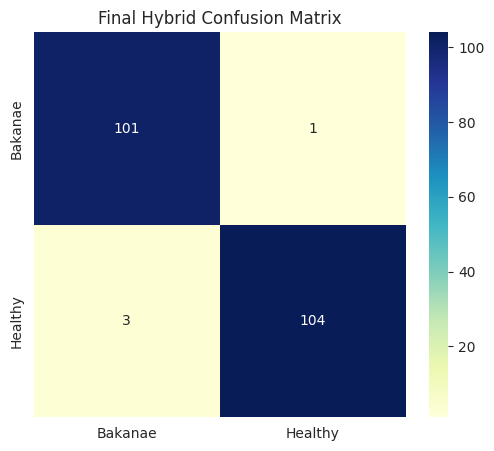

In [ ]:
# Training
print("\nStarting Hybrid Training...")
start_train = time.time()
history = hybrid_model.fit(
    x=[X_train_img, X_train_hand_scaled], y=y_train,
    validation_data=([X_test_img, X_test_hand_scaled], y_test),
    epochs=15, batch_size=16, verbose=1
)
train_time = time.time() - start_train

# Inference & Metrics
start_test = time.time()
y_probs = hybrid_model.predict([X_test_img, X_test_hand_scaled]).ravel()
test_time = time.time() - start_test

y_pred = (y_probs > 0.5).astype(int)

# Results Printout
print("\n" + "="*40)
print("HYBRID MODEL PERFORMANCE (BLOCK 4)")
print("="*40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Latency:   {(test_time/len(y_test))*1000:.2f} ms/img")
print("="*40)

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title('Final Hybrid Confusion Matrix')
plt.show()

In [ ]:
def build_hybrid_block4(hand_feature_count):
    # Branch 1: Pruned CNN
    img_input = layers.Input(shape=(160, 160, 3), name="image_input")
    base = tf.keras.applications.MobileNetV3Small(input_shape=(160, 160, 3), include_top=False, weights='imagenet')

    # Exit at Block 4 (expanded_conv_3)
    exit_layer = base.get_layer('expanded_conv_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer, name="backbone_block4")
    pruned_backbone.trainable = False

    x = tf.keras.applications.mobilenet_v3.preprocess_input(img_input)
    x = pruned_backbone(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Branch 2: Handcrafted
    hand_input = layers.Input(shape=(hand_feature_count,), name="hand_input")
    y = layers.Dense(16, activation='relu')(hand_input)
    y = layers.BatchNormalization()(y)

    # Fusion and Head
    combined = layers.concatenate([x, y])
    z = layers.Dense(32, activation='relu')(combined)
    z = layers.Dropout(0.3)(z)
    output = layers.Dense(1, activation='sigmoid')(z)

    model = models.Model(inputs=[img_input, hand_input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

hybrid_model = build_hybrid_block4(X_train_hand_scaled.shape[1])
hybrid_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "functional_66"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 160, 160,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ hand_input          │ (None, 11)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ backbone_block4     │ (None, 40, 40,    │      1,304 │ image_input[0][0] │
│ (Functional)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_73 (Dense)    │ (None, 16)        │        192 │ hand_input[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 16)        │          0 │ backbone_block4[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 16)        │         64 │ dense_73[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 32)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_74 (Dense)    │ (None, 32)        │      1,056 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_10          │ (None, 32)        │          0 │ dense_74[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_75 (Dense)    │ (None, 1)         │         33 │ dropout_10[0][0]  │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,649 (10.35 KB)

 Trainable params: 1,313 (5.13 KB)

 Non-trainable params: 1,336 (5.22 KB)


Starting Hybrid Training...
Epoch 1/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 7s 55ms/step - accuracy: 0.7395 - loss: 0.5197 - val_accuracy: 0.9569 - val_loss: 0.3527
Epoch 2/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.8920 - loss: 0.3160 - val_accuracy: 0.9522 - val_loss: 0.2421
Epoch 3/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - accuracy: 0.9112 - loss: 0.2649 - val_accuracy: 0.9665 - val_loss: 0.1926
Epoch 4/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9208 - loss: 0.2282 - val_accuracy: 0.9665 - val_loss: 0.1700
Epoch 5/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 65ms/step - accuracy: 0.9376 - loss: 0.2078 - val_accuracy: 0.9665 - val_loss: 0.1536
Epoch 6/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 56ms/step - accuracy: 0.9244 - loss: 0.2085 - val_accuracy: 0.9713 - val_loss: 0.1449
Epoch 7/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9400 - loss: 0.1946 - val_accuracy: 0.9713 - val_loss: 0.1393
Epoch 8/15
53/53 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9424 - loss: 0.18

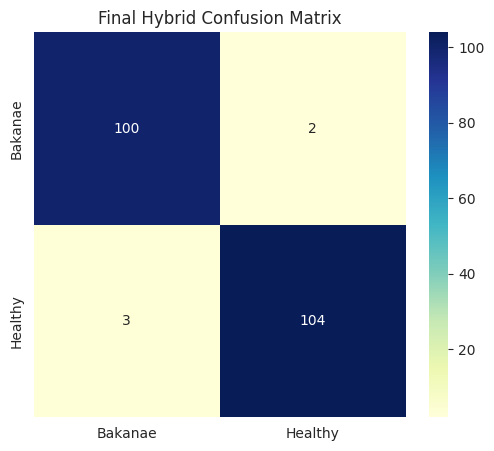

In [ ]:
# Training
print("\nStarting Hybrid Training...")
start_train = time.time()
history = hybrid_model.fit(
    x=[X_train_img, X_train_hand_scaled], y=y_train,
    validation_data=([X_test_img, X_test_hand_scaled], y_test),
    epochs=15, batch_size=16, verbose=1
)
train_time = time.time() - start_train

# Inference & Metrics
start_test = time.time()
y_probs = hybrid_model.predict([X_test_img, X_test_hand_scaled]).ravel()
test_time = time.time() - start_test

y_pred = (y_probs > 0.5).astype(int)

# Results Printout
print("\n" + "="*40)
print("HYBRID MODEL PERFORMANCE (BLOCK 1)")
print("="*40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Latency:   {(test_time/len(y_test))*1000:.2f} ms/img")
print("="*40)

# Confusion Matrix Visualization
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
            xticklabels=['Bakanae', 'Healthy'], yticklabels=['Bakanae', 'Healthy'])
plt.title('Final Hybrid Confusion Matrix')
plt.show()

In [ ]:
##5Fold cross validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# --- 1. MODEL ARCHITECTURE FUNCTION ---
def get_hybrid_model(hand_feature_count):
    # CNN Branch
    img_input = layers.Input(shape=(160, 160, 3), name="image_input")
    base = tf.keras.applications.MobileNetV3Small(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
    exit_layer = base.get_layer('expanded_conv_3_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    x = tf.keras.applications.mobilenet_v3.preprocess_input(img_input)
    x = pruned_backbone(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Handcrafted Branch
    hand_input = layers.Input(shape=(hand_feature_count,), name="hand_input")
    y = layers.Dense(16, activation='relu')(hand_input)
    y = layers.BatchNormalization()(y)

    # Fusion
    combined = layers.concatenate([x, y])
    z = layers.Dense(32, activation='relu')(combined)
    z = layers.Dropout(0.3)(z)
    output = layers.Dense(1, activation='sigmoid')(z)

    model = models.Model(inputs=[img_input, hand_input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# Combine all data for CV (assuming you have full arrays X_all_img, X_all_hand, y_all)
# If you only have train/test split, concatenate them first:
X_all_img = np.concatenate([X_train_img, X_test_img], axis=0)
X_all_hand = np.concatenate([X_train_hand_scaled, X_test_hand_scaled], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
cv_accuracies = []
cv_recalls = []

for train_idx, val_idx in skf.split(X_all_img, y_all):
    print(f"\n" + "-"*30)
    print(f"TRAINING FOLD {fold_no}")
    print("-"*30)

    # Split Data
    img_train, img_val = X_all_img[train_idx], X_all_img[val_idx]
    hand_train, hand_val = X_all_hand[train_idx], X_all_hand[val_idx]
    label_train, label_val = y_all[train_idx], y_all[val_idx]

    # Build and Train
    model = get_hybrid_model(X_all_hand.shape[1])
    model.fit(
        x=[img_train, hand_train], y=label_train,
        validation_data=([img_val, hand_val], label_val),
        epochs=10, batch_size=16, verbose=0 # Verbose 0 to keep output clean
    )

    # Evaluate Fold
    y_probs = model.predict([img_val, hand_val]).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    acc = accuracy_score(label_val, y_pred)
    rec = recall_score(label_val, y_pred)

    cv_accuracies.append(acc)
    cv_recalls.append(rec)

    print(f"Fold {fold_no} Results -> Accuracy: {acc:.4f}, Recall: {rec:.4f}")
    fold_no += 1


------------------------------
TRAINING FOLD 1
------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step
Fold 1 Results -> Accuracy: 0.9761, Recall: 0.9533

------------------------------
TRAINING FOLD 2
------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step
Fold 2 Results -> Accuracy: 0.9617, Recall: 0.9720

------------------------------
TRAINING FOLD 3
------------------------------


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 182ms/step
Fold 3 Results -> Accuracy: 0.9856, Recall: 0.9811

------------------------------
TRAINING FOLD 4
------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 266ms/step
Fold 4 Results -> Accuracy: 0.9519, Recall: 0.9528

------------------------------
TRAINING FOLD 5
------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step   
Fold 5 Results -> Accuracy: 0.9856, Recall: 0.9720



FINAL CROSS-VALIDATION SUMMARY
Mean Accuracy: 0.9722 (+/- 0.0134)
Mean Recall:   0.9662 (+/- 0.0113)


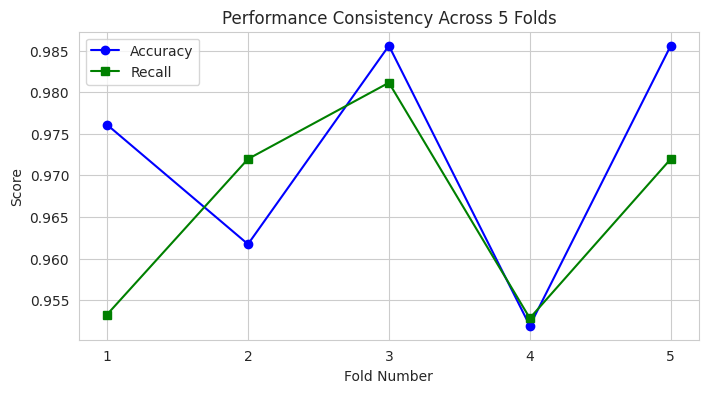

In [ ]:
print("\n" + "="*40)
print("FINAL CROSS-VALIDATION SUMMARY")
print("="*40)
print(f"Mean Accuracy: {np.mean(cv_accuracies):.4f} (+/- {np.std(cv_accuracies):.4f})")
print(f"Mean Recall:   {np.mean(cv_recalls):.4f} (+/- {np.std(cv_recalls):.4f})")
print("="*40)

# Visualizing Fold Stability
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_accuracies, marker='o', label='Accuracy', color='blue')
plt.plot(range(1, 6), cv_recalls, marker='s', label='Recall', color='green')
plt.title('Performance Consistency Across 5 Folds')
plt.xlabel('Fold Number')
plt.ylabel('Score')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import StratifiedKFold
import numpy as np

# --- 1. MODEL ARCHITECTURE FUNCTION ---
def get_hybrid_model(hand_feature_count):
    # CNN Branch
    img_input = layers.Input(shape=(160, 160, 3), name="image_input")
    base = tf.keras.applications.MobileNetV3Small(input_shape=(160, 160, 3), include_top=False, weights='imagenet')
    exit_layer = base.get_layer('expanded_conv_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    x = tf.keras.applications.mobilenet_v3.preprocess_input(img_input)
    x = pruned_backbone(x)
    x = layers.GlobalAveragePooling2D()(x)

    # Handcrafted Branch
    hand_input = layers.Input(shape=(hand_feature_count,), name="hand_input")
    y = layers.Dense(16, activation='relu')(hand_input)
    y = layers.BatchNormalization()(y)

    # Fusion
    combined = layers.concatenate([x, y])
    z = layers.Dense(32, activation='relu')(combined)
    z = layers.Dropout(0.3)(z)
    output = layers.Dense(1, activation='sigmoid')(z)

    model = models.Model(inputs=[img_input, hand_input], outputs=output)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [ ]:
# Combine all data for CV (assuming you have full arrays X_all_img, X_all_hand, y_all)
# If you only have train/test split, concatenate them first:
X_all_img = np.concatenate([X_train_img, X_test_img], axis=0)
X_all_hand = np.concatenate([X_train_hand_scaled, X_test_hand_scaled], axis=0)
y_all = np.concatenate([y_train, y_test], axis=0)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_no = 1
cv_accuracies = []
cv_recalls = []

for train_idx, val_idx in skf.split(X_all_img, y_all):
    print(f"\n" + "-"*30)
    print(f"TRAINING FOLD {fold_no}")
    print("-"*30)

    # Split Data
    img_train, img_val = X_all_img[train_idx], X_all_img[val_idx]
    hand_train, hand_val = X_all_hand[train_idx], X_all_hand[val_idx]
    label_train, label_val = y_all[train_idx], y_all[val_idx]

    # Build and Train
    model = get_hybrid_model(X_all_hand.shape[1])
    model.fit(
        x=[img_train, hand_train], y=label_train,
        validation_data=([img_val, hand_val], label_val),
        epochs=10, batch_size=16, verbose=0 # Verbose 0 to keep output clean
    )

    # Evaluate Fold
    y_probs = model.predict([img_val, hand_val]).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    acc = accuracy_score(label_val, y_pred)
    rec = recall_score(label_val, y_pred)

    cv_accuracies.append(acc)
    cv_recalls.append(rec)

    print(f"Fold {fold_no} Results -> Accuracy: {acc:.4f}, Recall: {rec:.4f}")
    fold_no += 1


------------------------------
TRAINING FOLD 1
------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step
Fold 1 Results -> Accuracy: 0.9761, Recall: 0.9533

------------------------------
TRAINING FOLD 2
------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 181ms/step
Fold 2 Results -> Accuracy: 0.9617, Recall: 0.9720

------------------------------
TRAINING FOLD 3
------------------------------


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 184ms/step
Fold 3 Results -> Accuracy: 0.9760, Recall: 0.9623

------------------------------
TRAINING FOLD 4
------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 195ms/step
Fold 4 Results -> Accuracy: 0.9567, Recall: 0.9528

------------------------------
TRAINING FOLD 5
------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step
Fold 5 Results -> Accuracy: 0.9904, Recall: 0.9813



FINAL CROSS-VALIDATION SUMMARY
Mean Accuracy: 0.9722 (+/- 0.0119)
Mean Recall:   0.9643 (+/- 0.0110)


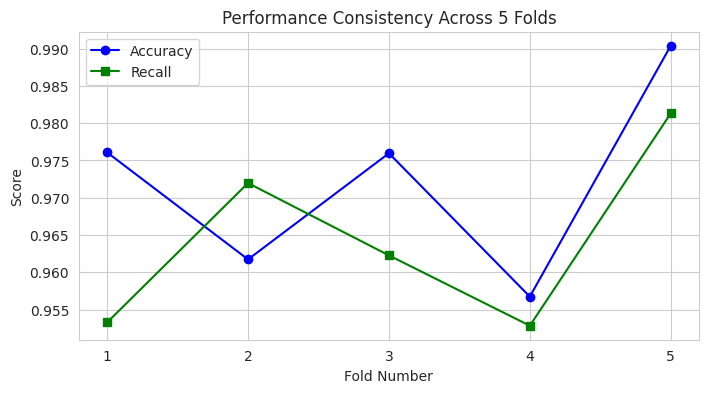

In [ ]:
print("\n" + "="*40)
print("FINAL CROSS-VALIDATION SUMMARY")
print("="*40)
print(f"Mean Accuracy: {np.mean(cv_accuracies):.4f} (+/- {np.std(cv_accuracies):.4f})")
print(f"Mean Recall:   {np.mean(cv_recalls):.4f} (+/- {np.std(cv_recalls):.4f})")
print("="*40)

# Visualizing Fold Stability
plt.figure(figsize=(8, 4))
plt.plot(range(1, 6), cv_accuracies, marker='o', label='Accuracy', color='blue')
plt.plot(range(1, 6), cv_recalls, marker='s', label='Recall', color='green')
plt.title('Performance Consistency Across 5 Folds')
plt.xlabel('Fold Number')
plt.ylabel('Score')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Define the indices for our feature groups based on your extraction vector
feature_groups = {
    "Full (All 10)": list(range(11)), # All features
    "No Color": list(range(6, 11)),    # Only Texture + Shape
    "No Texture": [0,1,2,3,4,5,10],    # Only Color + Shape
    "No Shape": list(range(10)),       # Only Color + Texture
    "Color Only": list(range(6)),      # Only Color
}

ablation_results = []

for name, indices in feature_groups.items():
    print(f"\n--- Running Ablation: {name} ---")

    # Filter the handcrafted features for this specific test
    X_train_filtered = X_train_hand_scaled[:, indices]
    X_test_filtered = X_test_hand_scaled[:, indices]

    # Build a fresh model for this subset
    model = get_hybrid_model(len(indices)) # Uses your Block 4 builder

    # Train quickly (5-10 epochs is enough for ablation trends)
    model.fit(
        x=[X_train_img, X_train_filtered], y=y_train,
        validation_data=([X_test_img, X_test_filtered], y_test),
        epochs=8, batch_size=16, verbose=0
    )

    # Evaluate
    y_probs = model.predict([X_test_img, X_test_filtered]).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)

    ablation_results.append({"Configuration": name, "Accuracy": acc, "Recall": rec})
    print(f"Result -> Acc: {acc:.4f}, Recall: {rec:.4f}")


--- Running Ablation: Full (All 10) ---


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 276ms/step
Result -> Acc: 0.9809, Recall: 0.9813

--- Running Ablation: No Color ---


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 295ms/step
Result -> Acc: 0.9761, Recall: 0.9720

--- Running Ablation: No Texture ---


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 186ms/step
Result -> Acc: 0.9809, Recall: 0.9720

--- Running Ablation: No Shape ---


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 177ms/step
Result -> Acc: 0.9713, Recall: 0.9720

--- Running Ablation: Color Only ---


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 166ms/step
Result -> Acc: 0.9713, Recall: 0.9626


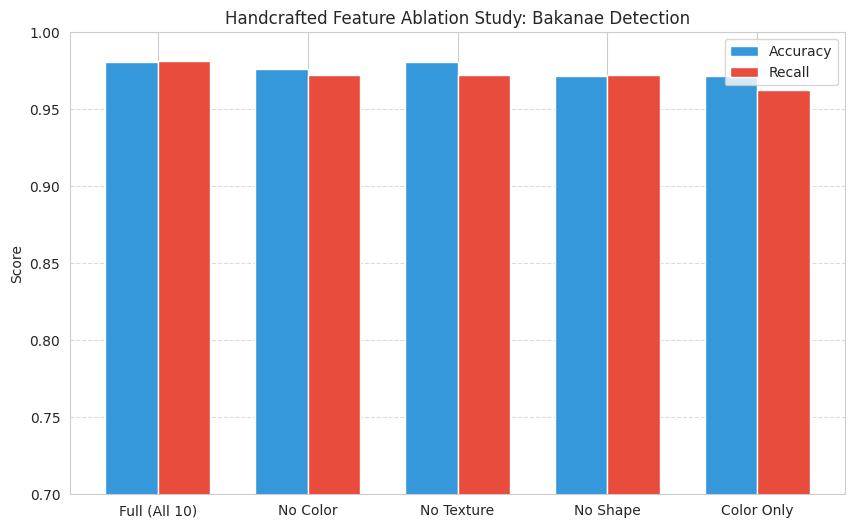

In [ ]:
import pandas as pd

df_ablation = pd.DataFrame(ablation_results)

plt.figure(figsize=(10, 6))
x = np.arange(len(df_ablation))
width = 0.35

plt.bar(x - width/2, df_ablation['Accuracy'], width, label='Accuracy', color='#3498db')
plt.bar(x + width/2, df_ablation['Recall'], width, label='Recall', color='#e74c3c')

plt.ylabel('Score')
plt.title('Handcrafted Feature Ablation Study: Bakanae Detection')
plt.xticks(x, df_ablation['Configuration'])
plt.ylim(0.7, 1.0) # Zoom in on the top to see the differences
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# --- BLOCK 1: DATA LOADING ---
# Assuming train_ds and test_ds exist from image_dataset_from_directory
def prepare_lite_data(ds_list):
    images, labels = [], []
    for ds in ds_list:
        for img, lbl in ds.unbatch():
            images.append(img.numpy())
            labels.append(lbl.numpy())
    return np.array(images), np.array(labels)

X_all, y_all = prepare_lite_data([train_ds, test_ds])

# --- BLOCK 2: NORMALIZATION ---
# MobileNetV3 expects specific scaling; we use the built-in utility
X_all_preprocessed = tf.keras.applications.mobilenet_v3.preprocess_input(X_all)

# --- BLOCK 3: CV PARTITIONING SETUP ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Total Images for Lite Model: {X_all.shape[0]}")

Total Images for Lite Model: 1042


In [ ]:
def build_lite_block2_model():
    # MobileNetV3 Small with Alpha 0.75 (lowest supported for ImageNet weights)
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet',
        alpha=0.75
    )

    # Pruning at Block 2
    exit_layer = base.get_layer('expanded_conv_1_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        pruned_backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Print Architecture and Params
lite_sample = build_lite_block2_model()
lite_sample.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


2910456/2910456 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential_35"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_35 (Lambda)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_97 (Functional)      │ (None, 20, 20, 24)     │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_52     │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_121 (Dense)               │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_122 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 5,504 (21.50 KB)


Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step
Fold 1 - Acc: 0.9569 | Rec: 0.9346 | F1: 0.9569


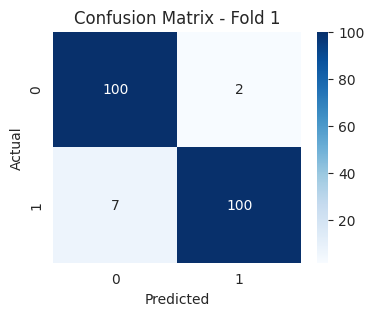


Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step
Fold 2 - Acc: 0.9665 | Rec: 0.9533 | F1: 0.9668


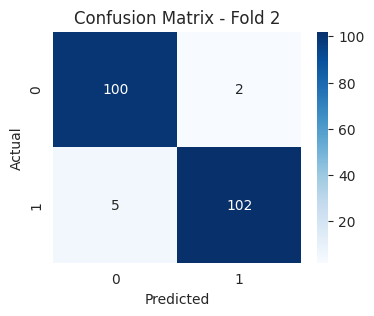


Training Fold 3...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step
Fold 3 - Acc: 0.9663 | Rec: 0.9717 | F1: 0.9671


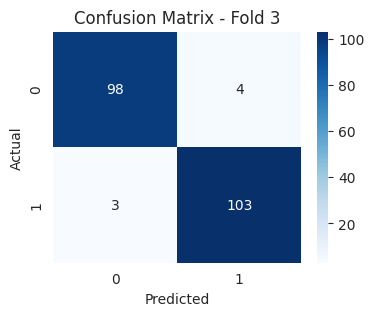


Training Fold 4...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step
Fold 4 - Acc: 0.9567 | Rec: 0.9528 | F1: 0.9573


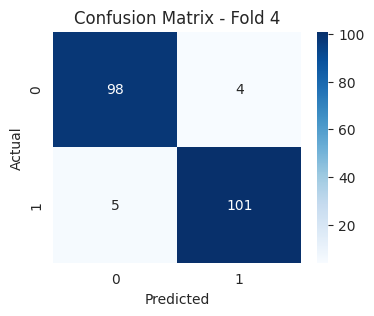


Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step
Fold 5 - Acc: 0.9808 | Rec: 0.9626 | F1: 0.9810


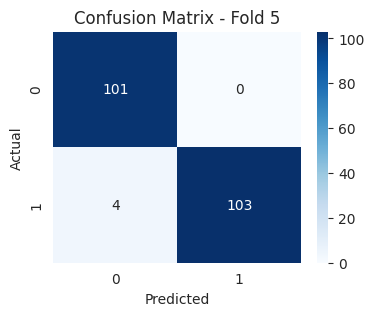


FINAL AVERAGE EVALUATION (5-FOLD)
Avg Accuracy:  0.9655
Avg F1-Score:  0.9658
Avg Recall:    0.9550
Avg AUC-ROC:   0.9820


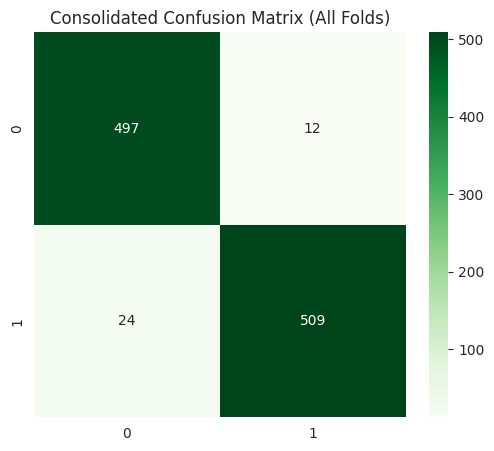

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
cumulative_cm = np.zeros((2, 2))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\nTraining Fold {fold}...")

    # Split
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Build & Train
    model = build_lite_block2_model()
    model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

    # Predict
    y_probs = model.predict(X_val).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Per-Fold Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_probs)
    cm = confusion_matrix(y_val, y_pred)

    all_metrics.append([acc, f1, rec, auc])
    cumulative_cm += cm

    # Print Individual Fold Results
    print(f"Fold {fold} - Acc: {acc:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    # Plot Individual Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# --- FINAL EVALUATION SUMMARY ---
avg_results = np.mean(all_metrics, axis=0)

print("\n" + "="*40)
print("FINAL AVERAGE EVALUATION (5-FOLD)")
print("="*40)
print(f"Avg Accuracy:  {avg_results[0]:.4f}")
print(f"Avg F1-Score:  {avg_results[1]:.4f}")
print(f"Avg Recall:    {avg_results[2]:.4f}")
print(f"Avg AUC-ROC:   {avg_results[3]:.4f}")
print("="*40)

# Consolidated Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cumulative_cm, annot=True, fmt='g', cmap='Greens')
plt.title('Consolidated Confusion Matrix (All Folds)')
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, recall_score,
                             roc_auc_score, confusion_matrix)
import matplotlib.pyplot as plt
import seaborn as sns

# --- BLOCK 1: DATA LOADING ---
# Assuming train_ds and test_ds exist from image_dataset_from_directory
def prepare_lite_data(ds_list):
    images, labels = [], []
    for ds in ds_list:
        for img, lbl in ds.unbatch():
            images.append(img.numpy())
            labels.append(lbl.numpy())
    return np.array(images), np.array(labels)

X_all, y_all = prepare_lite_data([train_ds, test_ds])

# --- BLOCK 2: NORMALIZATION ---
# MobileNetV3 expects specific scaling; we use the built-in utility
X_all_preprocessed = tf.keras.applications.mobilenet_v3.preprocess_input(X_all)

# --- BLOCK 3: CV PARTITIONING SETUP ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f"Total Images for Lite Model: {X_all.shape[0]}")

Total Images for Lite Model: 1042


In [ ]:
def build_lite_block2_model():
    # MobileNetV3 Small with Alpha 0.75 (lowest supported for ImageNet weights)
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet',
        alpha=0.75
    )

    # Pruning at Block 1
    exit_layer = base.get_layer('expanded_conv_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        pruned_backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Print Architecture and Params
lite_sample = build_lite_block2_model()
lite_sample.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "sequential_41"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_41 (Lambda)              │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_109 (Functional)     │ (None, 40, 40, 16)     │         1,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_58     │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_133 (Dense)               │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_134 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,593 (6.22 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 1,304 (5.09 KB)


Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
Fold 1 - Acc: 0.9282 | Rec: 0.9159 | F1: 0.9289


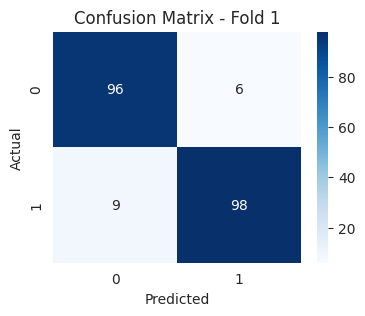


Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 132ms/step
Fold 2 - Acc: 0.9091 | Rec: 0.9159 | F1: 0.9116


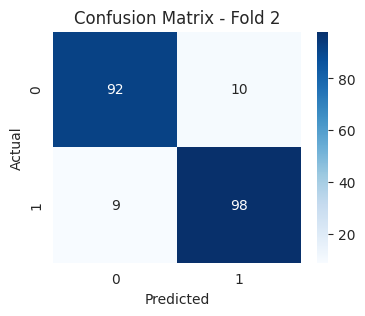


Training Fold 3...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 92ms/step
Fold 3 - Acc: 0.9567 | Rec: 0.9623 | F1: 0.9577


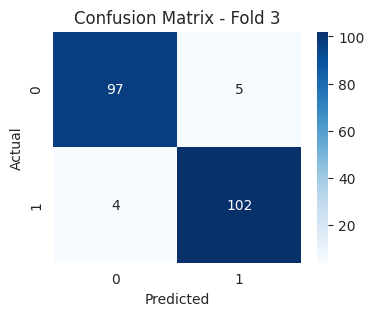


Training Fold 4...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 101ms/step
Fold 4 - Acc: 0.9327 | Rec: 0.9528 | F1: 0.9352


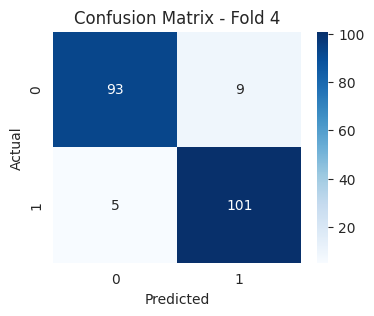


Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step
Fold 5 - Acc: 0.9471 | Rec: 0.9252 | F1: 0.9474


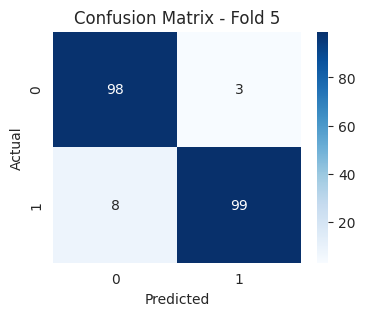


FINAL AVERAGE EVALUATION (5-FOLD)
Avg Accuracy:  0.9348
Avg F1-Score:  0.9362
Avg Recall:    0.9344
Avg AUC-ROC:   0.9687


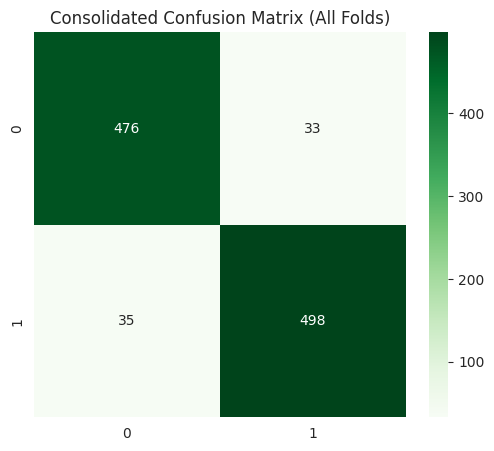

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
cumulative_cm = np.zeros((2, 2))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\nTraining Fold {fold}...")

    # Split
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Build & Train
    model = build_lite_block2_model()
    model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

    # Predict
    y_probs = model.predict(X_val).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Per-Fold Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_probs)
    cm = confusion_matrix(y_val, y_pred)

    all_metrics.append([acc, f1, rec, auc])
    cumulative_cm += cm

    # Print Individual Fold Results
    print(f"Fold {fold} - Acc: {acc:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    # Plot Individual Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# --- FINAL EVALUATION SUMMARY ---
avg_results = np.mean(all_metrics, axis=0)

print("\n" + "="*40)
print("FINAL AVERAGE EVALUATION (5-FOLD)")
print("="*40)
print(f"Avg Accuracy:  {avg_results[0]:.4f}")
print(f"Avg F1-Score:  {avg_results[1]:.4f}")
print(f"Avg Recall:    {avg_results[2]:.4f}")
print(f"Avg AUC-ROC:   {avg_results[3]:.4f}")
print("="*40)

# Consolidated Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cumulative_cm, annot=True, fmt='g', cmap='Greens')
plt.title('Consolidated Confusion Matrix (All Folds)')
plt.show()

In [ ]:
def build_lite_block2_model():
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet',
        alpha=1.0
    )

    # Pruning at Block 1
    exit_layer = base.get_layer('expanded_conv_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        pruned_backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Print Architecture and Params
lite_sample = build_lite_block2_model()
lite_sample.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 40, 40, 16)     │         1,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 16)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,593 (6.22 KB)

 Trainable params: 289 (1.13 KB)

 Non-trainable params: 1,304 (5.09 KB)


Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
Fold 1 - Acc: 0.9426 | Rec: 0.9439 | F1: 0.9439


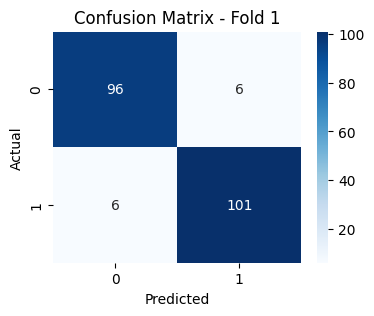


Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step
Fold 2 - Acc: 0.9282 | Rec: 0.9252 | F1: 0.9296


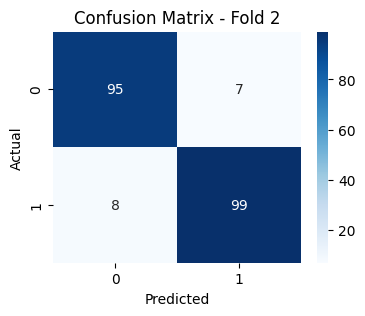


Training Fold 3...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step
Fold 3 - Acc: 0.9423 | Rec: 0.9340 | F1: 0.9429


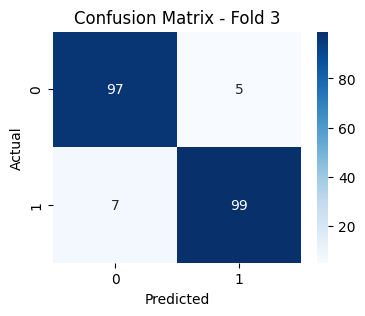


Training Fold 4...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step
Fold 4 - Acc: 0.9519 | Rec: 0.9528 | F1: 0.9528


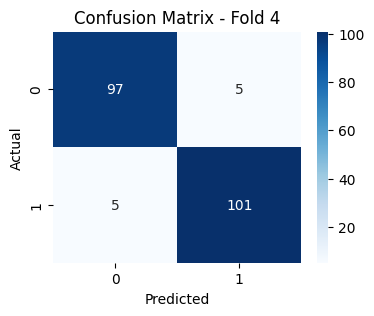


Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step
Fold 5 - Acc: 0.9519 | Rec: 0.9439 | F1: 0.9528


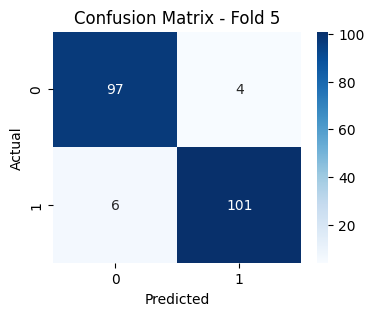


FINAL AVERAGE EVALUATION (5-FOLD)
Avg Accuracy:  0.9434
Avg F1-Score:  0.9444
Avg Recall:    0.9400
Avg AUC-ROC:   0.9716


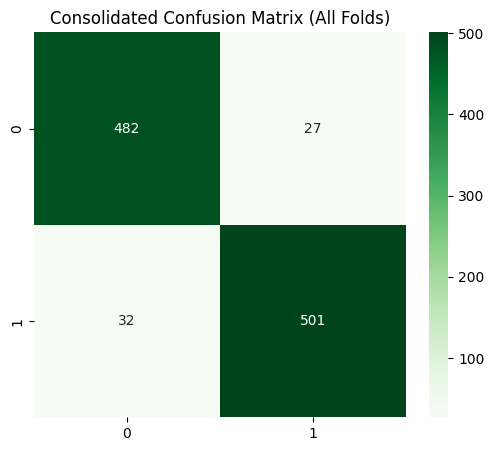

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
cumulative_cm = np.zeros((2, 2))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\nTraining Fold {fold}...")

    # Split
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Build & Train
    model = build_lite_block2_model()
    model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

    # Predict
    y_probs = model.predict(X_val).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Per-Fold Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_probs)
    cm = confusion_matrix(y_val, y_pred)

    all_metrics.append([acc, f1, rec, auc])
    cumulative_cm += cm

    # Print Individual Fold Results
    print(f"Fold {fold} - Acc: {acc:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    # Plot Individual Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# --- FINAL EVALUATION SUMMARY ---
avg_results = np.mean(all_metrics, axis=0)

print("\n" + "="*40)
print("FINAL AVERAGE EVALUATION (5-FOLD)")
print("="*40)
print(f"Avg Accuracy:  {avg_results[0]:.4f}")
print(f"Avg F1-Score:  {avg_results[1]:.4f}")
print(f"Avg Recall:    {avg_results[2]:.4f}")
print(f"Avg AUC-ROC:   {avg_results[3]:.4f}")
print("="*40)

# Consolidated Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cumulative_cm, annot=True, fmt='g', cmap='Greens')
plt.title('Consolidated Confusion Matrix (All Folds)')
plt.show()

In [ ]:
def build_lite_block2_model():
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet',
        alpha=1.0
    )

    # Pruning at Block 2
    exit_layer = base.get_layer('expanded_conv_1_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        pruned_backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Print Architecture and Params
lite_sample = build_lite_block2_model()
lite_sample.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_6 (Lambda)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_12 (Functional)      │ (None, 20, 20, 24)     │         5,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 24)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,921 (23.13 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 5,504 (21.50 KB)


Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step
Fold 1 - Acc: 0.9522 | Rec: 0.9346 | F1: 0.9524


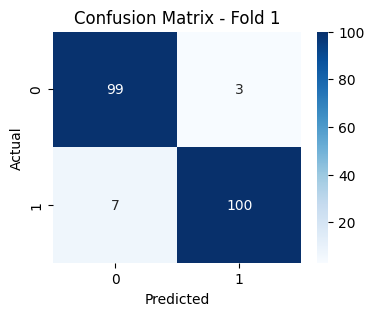


Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 108ms/step
Fold 2 - Acc: 0.9713 | Rec: 0.9720 | F1: 0.9720


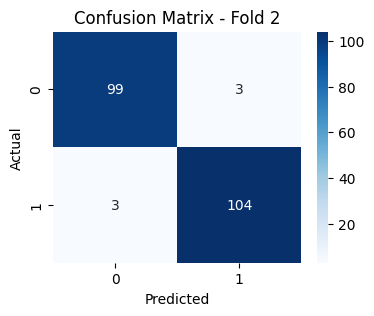


Training Fold 3...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step
Fold 3 - Acc: 0.9760 | Rec: 0.9811 | F1: 0.9765


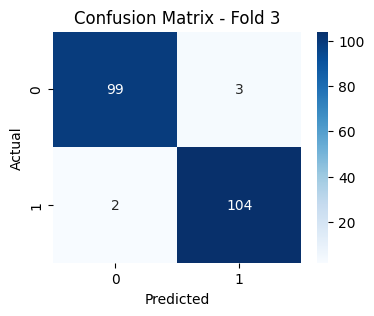


Training Fold 4...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 104ms/step
Fold 4 - Acc: 0.9423 | Rec: 0.9528 | F1: 0.9439


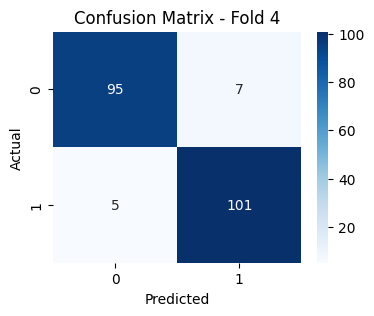


Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 143ms/step
Fold 5 - Acc: 0.9808 | Rec: 0.9626 | F1: 0.9810


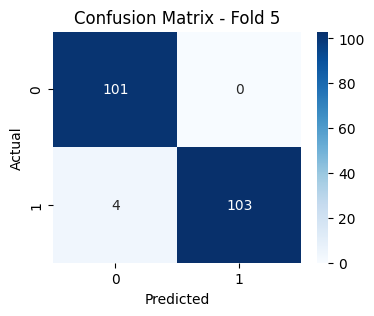


FINAL AVERAGE EVALUATION (5-FOLD)
Avg Accuracy:  0.9645
Avg F1-Score:  0.9651
Avg Recall:    0.9606
Avg AUC-ROC:   0.9845


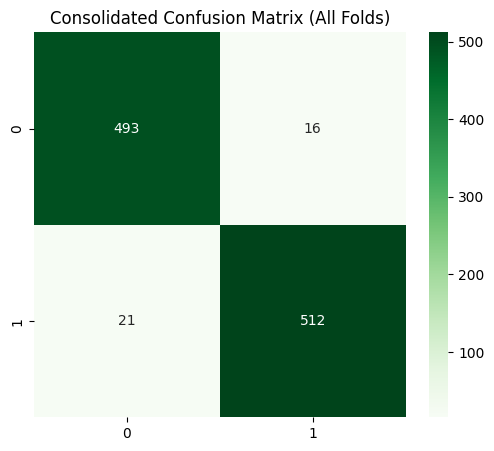

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
cumulative_cm = np.zeros((2, 2))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\nTraining Fold {fold}...")

    # Split
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Build & Train
    model = build_lite_block2_model()
    model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

    # Predict
    y_probs = model.predict(X_val).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Per-Fold Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_probs)
    cm = confusion_matrix(y_val, y_pred)

    all_metrics.append([acc, f1, rec, auc])
    cumulative_cm += cm

    # Print Individual Fold Results
    print(f"Fold {fold} - Acc: {acc:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    # Plot Individual Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# --- FINAL EVALUATION SUMMARY ---
avg_results = np.mean(all_metrics, axis=0)

print("\n" + "="*40)
print("FINAL AVERAGE EVALUATION (5-FOLD)")
print("="*40)
print(f"Avg Accuracy:  {avg_results[0]:.4f}")
print(f"Avg F1-Score:  {avg_results[1]:.4f}")
print(f"Avg Recall:    {avg_results[2]:.4f}")
print(f"Avg AUC-ROC:   {avg_results[3]:.4f}")
print("="*40)

# Consolidated Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cumulative_cm, annot=True, fmt='g', cmap='Greens')
plt.title('Consolidated Confusion Matrix (All Folds)')
plt.show()

In [ ]:
## 4 block

In [ ]:
def build_lite_block2_model():
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet',
        alpha=1.0
    )

    # Pruning at Block 4
    exit_layer = base.get_layer('expanded_conv_3_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        pruned_backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Print Architecture and Params
lite_sample = build_lite_block2_model()
lite_sample.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 10, 10, 40)     │        25,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 40)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,193 (102.32 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 25,520 (99.69 KB)


Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step
Fold 1 - Acc: 0.9569 | Rec: 0.9252 | F1: 0.9565


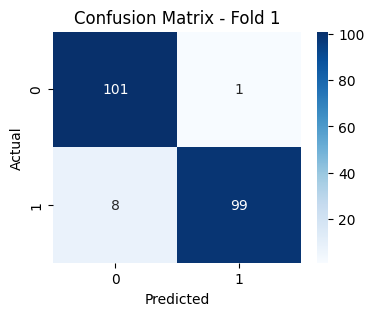


Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 141ms/step
Fold 2 - Acc: 0.9569 | Rec: 0.9626 | F1: 0.9581


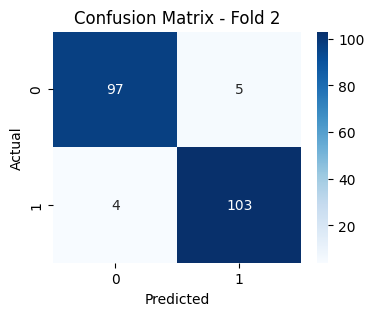


Training Fold 3...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step
Fold 3 - Acc: 0.9663 | Rec: 0.9623 | F1: 0.9668


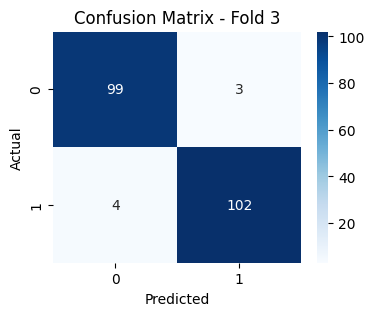


Training Fold 4...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step
Fold 4 - Acc: 0.9519 | Rec: 0.9528 | F1: 0.9528


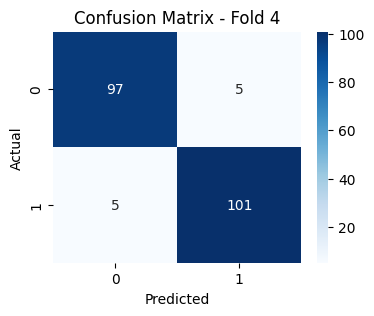


Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 138ms/step
Fold 5 - Acc: 0.9808 | Rec: 0.9626 | F1: 0.9810


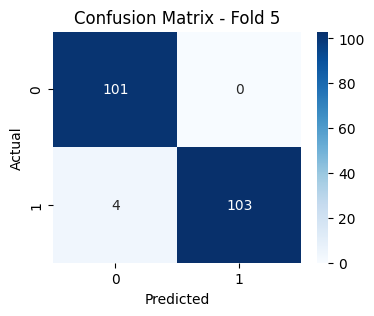


FINAL AVERAGE EVALUATION (5-FOLD)
Avg Accuracy:  0.9626
Avg F1-Score:  0.9631
Avg Recall:    0.9531
Avg AUC-ROC:   0.9881


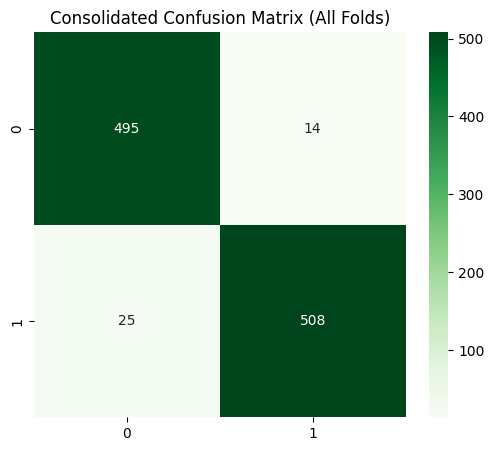

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
cumulative_cm = np.zeros((2, 2))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\nTraining Fold {fold}...")

    # Split
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Build & Train
    model = build_lite_block2_model()
    model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

    # Predict
    y_probs = model.predict(X_val).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Per-Fold Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_probs)
    cm = confusion_matrix(y_val, y_pred)

    all_metrics.append([acc, f1, rec, auc])
    cumulative_cm += cm

    # Print Individual Fold Results
    print(f"Fold {fold} - Acc: {acc:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    # Plot Individual Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# --- FINAL EVALUATION SUMMARY ---
avg_results = np.mean(all_metrics, axis=0)

print("\n" + "="*40)
print("FINAL AVERAGE EVALUATION (5-FOLD)")
print("="*40)
print(f"Avg Accuracy:  {avg_results[0]:.4f}")
print(f"Avg F1-Score:  {avg_results[1]:.4f}")
print(f"Avg Recall:    {avg_results[2]:.4f}")
print(f"Avg AUC-ROC:   {avg_results[3]:.4f}")
print("="*40)

# Consolidated Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cumulative_cm, annot=True, fmt='g', cmap='Greens')
plt.title('Consolidated Confusion Matrix (All Folds)')
plt.show()

In [ ]:
def build_lite_block2_model():
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet',
        alpha=1.0
    )

    # Pruning at Block 8
    exit_layer = base.get_layer('expanded_conv_7_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        pruned_backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Print Architecture and Params
lite_sample = build_lite_block2_model()
lite_sample.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_6 (Lambda)               │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_12 (Functional)      │ (None, 10, 10, 48)     │       195,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_6      │ (None, 48)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 16)             │           784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 195,945 (765.41 KB)

 Trainable params: 801 (3.13 KB)

 Non-trainable params: 195,144 (762.28 KB)


Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 345ms/step
Fold 1 - Acc: 0.9617 | Rec: 0.9346 | F1: 0.9615


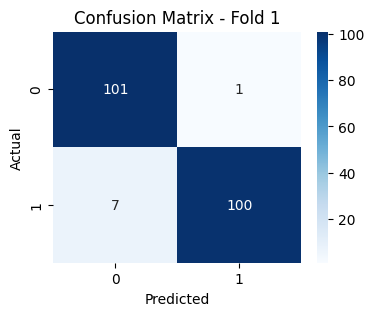


Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 295ms/step
Fold 2 - Acc: 0.9522 | Rec: 0.9439 | F1: 0.9528


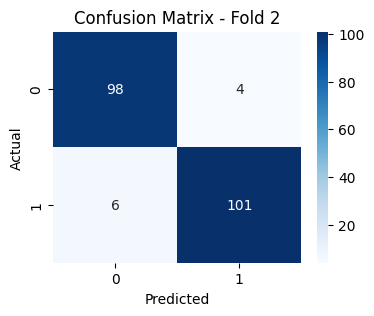


Training Fold 3...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step
Fold 3 - Acc: 0.9856 | Rec: 0.9906 | F1: 0.9859


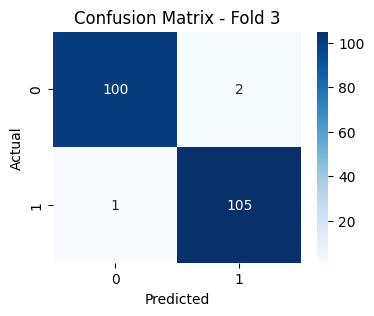


Training Fold 4...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 403ms/step
Fold 4 - Acc: 0.9615 | Rec: 0.9528 | F1: 0.9619


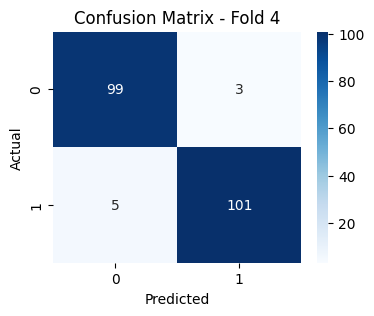


Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 254ms/step
Fold 5 - Acc: 0.9615 | Rec: 0.9626 | F1: 0.9626


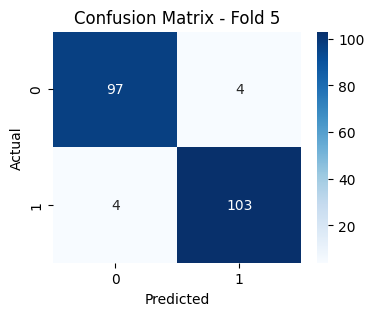


FINAL AVERAGE EVALUATION (5-FOLD)
Avg Accuracy:  0.9645
Avg F1-Score:  0.9650
Avg Recall:    0.9569
Avg AUC-ROC:   0.9905


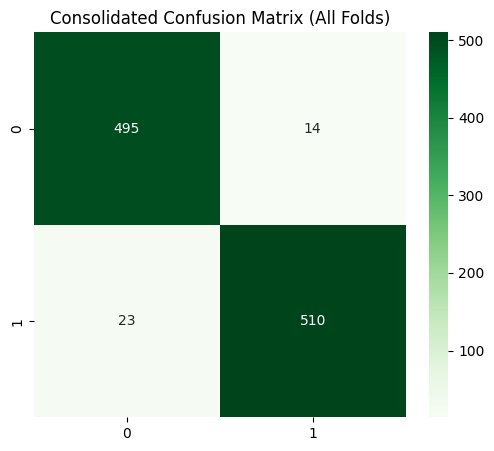

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
cumulative_cm = np.zeros((2, 2))

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\nTraining Fold {fold}...")

    # Split
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Build & Train
    model = build_lite_block2_model()
    model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

    # Predict
    y_probs = model.predict(X_val).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Per-Fold Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_probs)
    cm = confusion_matrix(y_val, y_pred)

    all_metrics.append([acc, f1, rec, auc])
    cumulative_cm += cm

    # Print Individual Fold Results
    print(f"Fold {fold} - Acc: {acc:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")

    # Plot Individual Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues')
    plt.title(f'Confusion Matrix - Fold {fold}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# --- FINAL EVALUATION SUMMARY ---
avg_results = np.mean(all_metrics, axis=0)

print("\n" + "="*40)
print("FINAL AVERAGE EVALUATION (5-FOLD)")
print("="*40)
print(f"Avg Accuracy:  {avg_results[0]:.4f}")
print(f"Avg F1-Score:  {avg_results[1]:.4f}")
print(f"Avg Recall:    {avg_results[2]:.4f}")
print(f"Avg AUC-ROC:   {avg_results[3]:.4f}")
print("="*40)

# Consolidated Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cumulative_cm, annot=True, fmt='g', cmap='Greens')
plt.title('Consolidated Confusion Matrix (All Folds)')
plt.show()

In [ ]:
#save

In [ ]:
def build_lite_block2_model():
    base = tf.keras.applications.MobileNetV3Small(
        input_shape=(160, 160, 3),
        include_top=False,
        weights='imagenet',
        alpha=1.0
    )

    # Pruning at Block 4
    exit_layer = base.get_layer('expanded_conv_3_project_bn').output
    pruned_backbone = models.Model(inputs=base.input, outputs=exit_layer)
    pruned_backbone.trainable = False

    model = models.Sequential([
        layers.Input(shape=(160, 160, 3)),
        layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input),
        pruned_backbone,
        layers.GlobalAveragePooling2D(),
        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Print Architecture and Params
lite_sample = build_lite_block2_model()
lite_sample.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional_20 (Functional)      │ (None, 10, 10, 40)     │        25,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 40)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,193 (102.32 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 25,520 (99.69 KB)

In [ ]:
import os

# Create a directory to save models if it doesn't exist
save_dir = '/content/drive/MyDrive/models'
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
all_metrics = []
cumulative_cm = np.zeros((2, 2))
best_accuracy = 0.0  # Track the best model across folds

for fold, (train_idx, val_idx) in enumerate(skf.split(X_all, y_all), 1):
    print(f"\nTraining Fold {fold}...")

    # Split
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]

    # Build & Train
    model = build_lite_block2_model()
    model.fit(X_train, y_train, epochs=10, batch_size=16, verbose=0)

    # Predict
    y_probs = model.predict(X_val).ravel()
    y_pred = (y_probs > 0.5).astype(int)

    # Per-Fold Metrics
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)
    rec = recall_score(y_val, y_pred)
    auc = roc_auc_score(y_val, y_probs)
    cm = confusion_matrix(y_val, y_pred)

    all_metrics.append([acc, f1, rec, auc])
    cumulative_cm += cm

    # --- SAVING LOGIC ---
    # Save the model from the current fold
    fold_save_path = os.path.join(save_dir, f'lite_block2_fold{fold}.keras')
    model.save(fold_save_path)

    # Track and save the absolute best model separately
    if acc > best_accuracy:
        best_accuracy = acc
        model.save(os.path.join(save_dir, 'lite_block2_best_overall.keras'))
        print(f"--> New Best Model Saved (Fold {fold} Acc: {acc:.4f})")

    print(f"Fold {fold} - Acc: {acc:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}")
    # ... [Rest of your plotting code] ...


Training Fold 1...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


6/7 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 150ms/step
--> New Best Model Saved (Fold 1 Acc: 0.9713)
Fold 1 - Acc: 0.9713 | Rec: 0.9439 | F1: 0.9712

Training Fold 2...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 149ms/step
--> New Best Model Saved (Fold 3 Acc: 0.9760)
Fold 3 - Acc: 0.9760 | Rec: 0.9811 | F1: 0.9765

Training Fold 4...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 236ms/step
Fold 4 - Acc: 0.9519 | Rec: 0.9528 | F1: 0.9528

Training Fold 5...


/usr/local/lib/python3.12/dist-packages/keras/src/applications/mobilenet_v3.py:454: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 144ms/step
Fold 5 - Acc: 0.9760 | Rec: 0.9813 | F1: 0.9767


Loading model from /content/drive/MyDrive/models/lite_block2_best_overall.keras...
Model loaded successfully!
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


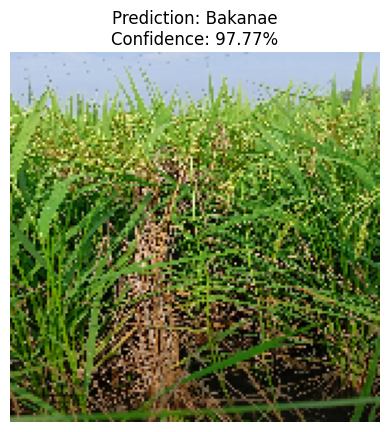

In [ ]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# 1. Import the specific preprocess function used during training
from tensorflow.keras.applications.mobilenet_v3 import preprocess_input

MODEL_PATH = '/content/drive/MyDrive/models/lite_block2_best_overall.keras'
CLASS_NAMES = ['Bakanae', 'Healthy']

# 2. Tell Keras how to handle the Lambda layer via custom_objects
print(f"Loading model from {MODEL_PATH}...")
model = tf.keras.models.load_model(
    MODEL_PATH,
    custom_objects={'preprocess_input': preprocess_input} # <-- The Fix
)
print("Model loaded successfully!")

def predict_custom_image(img_path, model, class_names):
    img = image.load_img(img_path, target_size=(160, 160)) # Note: Your model used 160x160
    img_array = image.img_to_array(img)

    # IMPORTANT: Do NOT manually divide by 255.0 here anymore!
    # Because the model already contains the Lambda layer with preprocess_input,
    # it will handle the scaling internally. Just expand the dimensions.
    img_array = np.expand_dims(img_array, axis=0)

    prediction_prob = model.predict(img_array)[0][0]

    predicted_class_idx = int(prediction_prob > 0.5)
    predicted_class_name = class_names[predicted_class_idx]
    confidence = prediction_prob if predicted_class_idx == 1 else (1.0 - prediction_prob)

    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Prediction: {predicted_class_name}\nConfidence: {confidence:.2%}")
    plt.show()

# Run the test
predict_custom_image('/content/drive/MyDrive/new dataset/Bakanae/IMG20240911095331.jpg', model, CLASS_NAMES)